# Methods review: feature scaling, skew, and choosing *k*

Companion diagnostics for the essay **"Indoor vs. Outdoor Heat in California's Prisons."**
This notebook re-opens the clustering decisions so they can be confirmed or revised:

1. **Are the nine features continuous, or bounded / zero-inflated?**
2. **Is any feature skewed — and does the current scaling (`StandardScaler`/z-score) address it?**
3. **How many clusters?** Elbow + silhouette + **ARI stability**, and specifically **k = 3 vs k = 4**.
4. **Does the method fit the data?** Address skew + zeros first, then compare **k-means (Euclidean)**
   against **Gower distance + K-Medoids (PAM)**, which is built for mixed continuous/categorical data.

The production pipeline (`build_indoor_outdoor_analysis.py`) standardizes the nine features with
`StandardScaler` and runs `KMeans(n_clusters=3, random_state=42, n_init=50)`. Nothing here
overwrites that pipeline or the essay; it only surfaces the diagnostics behind those choices.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25, 'font.size': 10})

RANDOM_STATE, N_INIT = 42, 25   # match build_indoor_outdoor_analysis.py (n_init 50 there; 25 is plenty for n=31)

## 1. Load data and define the nine clustering features

In [2]:
df = pd.read_csv('indoor_outdoor_heat_2025.csv')

FEATURES = ['year_opened', 'pct_hu_mechanical', 'pct_hu_evaporative',
            'days_outdoor_above_78f_2025', 'days_indoor_above_78f_2025', 'uhi_normalized',
            'elevation_m', 'latitude', 'hotnights_pre_pct']

# Same null handling as the production pipeline: the two missing UHI values -> 0 (and hotnights)
df['uhi_normalized']   = df['uhi_normalized'].fillna(0)
df['hotnights_pre_pct'] = df['hotnights_pre_pct'].fillna(0)

print(f'{len(df)} facilities, {len(FEATURES)} features')
df[['cdcr_code', 'cluster'] + FEATURES].head()

31 facilities, 9 features


,cdcr_code,cluster,year_opened,pct_hu_mechanical,pct_hu_evaporative,days_outdoor_above_78f_2025,days_indoor_above_78f_2025,uhi_normalized,elevation_m,latitude,hotnights_pre_pct
0,PBSP,A,1989.0,0.0345,0.0000,4,63,0.3096,30.0,41.854809,0.000000
1,CTF,A,1946.0,0.0000,0.0455,31,60,0.0000,65.0,36.469648,4.247950
2,RJD,A,1987.0,0.3478,0.0000,59,114,0.0000,180.0,32.584565,5.169667
3,SQ,A,1852.0,0.0000,0.0000,29,41,0.0000,1.0,37.940040,6.016209
4,CCI,A,1954.0,0.0455,0.0000,90,115,0.0000,1192.0,35.109916,9.043478


## 2. Are the features continuous?

k-means minimizes **Euclidean distance**, which implicitly assumes features are roughly
continuous and comparably scaled. Bounded shares (0–1) and features where many facilities sit at
exactly 0 ("zero-inflated") violate that — a block of identical zeros pulls those facilities
together regardless of anything else.

In [3]:
rows = []
for f in FEATURES:
    s = df[f]
    kind = ('share 0-1' if f.startswith(('pct_', 'uhi'))
            else 'count'  if 'days' in f
            else 'continuous')
    rows.append({'feature': f, 'kind': kind,
                 'min': round(s.min(), 3), 'max': round(s.max(), 3),
                 'n_unique': s.nunique(),
                 'n_zero': int((s == 0).sum()), 'pct_zero': round((s == 0).mean() * 100, 1)})
cont = pd.DataFrame(rows)
cont

,feature,kind,min,max,n_unique,n_zero,pct_zero
0,year_opened,continuous,1852.000,2013.000,25,0,0.0
1,pct_hu_mechanical,share 0-1,0.000,1.000,19,8,25.8
2,pct_hu_evaporative,share 0-1,0.000,1.000,16,11,35.5
3,days_outdoor_above_78f_2025,count,4.000,184.000,21,0,0.0
4,days_indoor_above_78f_2025,count,0.000,161.000,28,1,3.2
5,uhi_normalized,share 0-1,0.000,1.000,16,14,45.2
6,elevation_m,continuous,-48.000,1267.000,28,0,0.0
7,latitude,continuous,32.585,41.855,31,0,0.0
8,hotnights_pre_pct,continuous,0.000,12.080,25,2,6.5


**Read-out.** Three features are bounded shares with heavy zero-inflation
(`pct_hu_mechanical`, `pct_hu_evaporative`, `uhi_normalized`); `hotnights_pre_pct`
also has a block of zeros. `pct_hu_evaporative` even exceeds 1.0 at one facility
(SATF = 1.03), a data quirk worth fixing. `days_*` are bounded counts; only `year_opened`,
`elevation_m`, and `latitude` are genuinely continuous.

## 3. Skew of each feature (raw)

In [4]:
sk = pd.DataFrame({'skew': [skew(df[f]) for f in FEATURES]}, index=FEATURES)
sk['|skew|>1'] = sk['skew'].abs() > 1
sk.sort_values('skew', key=abs, ascending=False).round(2)

,skew,|skew|>1
elevation_m,2.69,True
year_opened,-2.18,True
pct_hu_mechanical,1.61,True
days_outdoor_above_78f_2025,-1.30,True
uhi_normalized,0.96,False
hotnights_pre_pct,-0.91,False
days_indoor_above_78f_2025,-0.37,False
latitude,0.33,False
pct_hu_evaporative,0.04,False


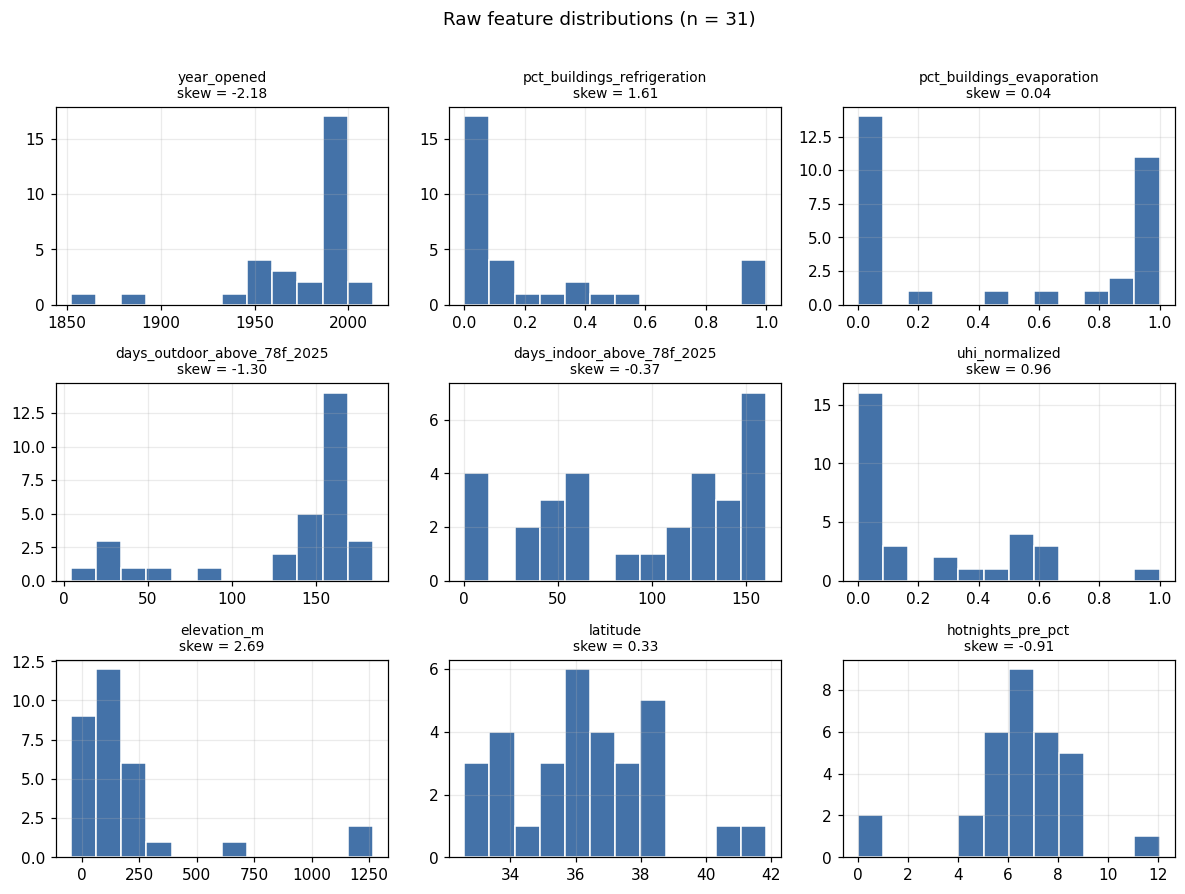

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for ax, f in zip(axes.ravel(), FEATURES):
    ax.hist(df[f], bins=12, color='#4472a8', edgecolor='white')
    ax.set_title(f'{f}\nskew = {skew(df[f]):.2f}', fontsize=9)
fig.suptitle('Raw feature distributions (n = 31)', y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

### Does `StandardScaler` address skew? No.

Z-scoring is a **linear** transform, `z = (x − mean)/std`. Skewness is invariant to shift and
scale, so the standardized features have *exactly* the same skew as the raw ones — standardizing
makes features comparable in scale but does nothing about shape.

In [6]:
z = StandardScaler().fit_transform(df[FEATURES])
comp = pd.DataFrame({'skew_raw':     [skew(df[f]) for f in FEATURES],
                     'skew_zscored': [skew(z[:, i]) for i in range(len(FEATURES))]},
                    index=FEATURES)
comp.round(3)

,skew_raw,skew_zscored
year_opened,-2.176,-2.176
pct_hu_mechanical,1.608,1.608
pct_hu_evaporative,0.044,0.044
days_outdoor_above_78f_2025,-1.303,-1.303
days_indoor_above_78f_2025,-0.371,-0.371
uhi_normalized,0.957,0.957
elevation_m,2.693,2.693
latitude,0.332,0.332
hotnights_pre_pct,-0.908,-0.908


## 4. A skew-correcting transform (Yeo-Johnson)

`PowerTransformer(method='yeo-johnson')` finds a power transform pulling each feature toward
normal, then standardizes. Yeo-Johnson (unlike a log) handles zeros and negatives, so it works on
`elevation_m` (below sea level at CAL/CEN) and the zero-inflated shares. Caveat: it tames a heavy
tail but **cannot manufacture continuity** — a feature that is 60% exact zeros stays a spike at
zero. For those the real question is the *method*, addressed in §8–9.

In [7]:
yj = PowerTransformer(method='yeo-johnson', standardize=True).fit_transform(df[FEATURES])
comp['skew_yeojohnson'] = [skew(yj[:, i]) for i in range(len(FEATURES))]
comp.sort_values('skew_raw', key=abs, ascending=False).round(3)

,skew_raw,skew_zscored,skew_yeojohnson
elevation_m,2.693,2.693,1.006
year_opened,-2.176,-2.176,-0.342
pct_hu_mechanical,1.608,1.608,0.533
days_outdoor_above_78f_2025,-1.303,-1.303,-0.941
uhi_normalized,0.957,0.957,0.401
hotnights_pre_pct,-0.908,-0.908,0.088
days_indoor_above_78f_2025,-0.371,-0.371,-0.560
latitude,0.332,0.332,0.012
pct_hu_evaporative,0.044,0.044,-0.008


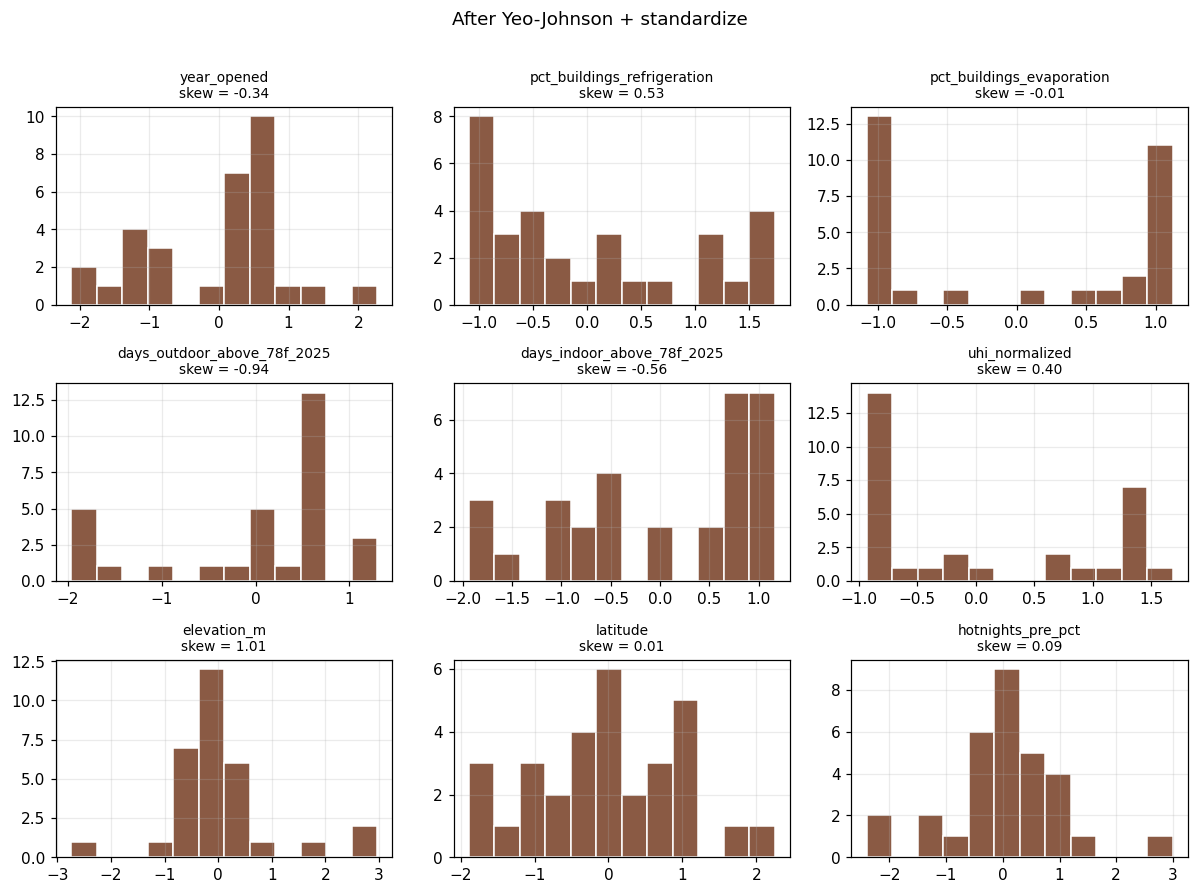

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(11, 8))
for i, (ax, f) in enumerate(zip(axes.ravel(), FEATURES)):
    ax.hist(yj[:, i], bins=12, color='#8a5a44', edgecolor='white')
    ax.set_title(f'{f}\nskew = {skew(yj[:, i]):.2f}', fontsize=9)
fig.suptitle('After Yeo-Johnson + standardize', y=1.01, fontsize=12)
fig.tight_layout(); plt.show()

## 5. How many clusters? Elbow + silhouette + **ARI stability**

Three diagnostics, each computed under **both** scalings (plain z-score = shipped, vs.
Yeo-Johnson = skew-corrected):

- **Elbow / inertia** — within-cluster sum of squares; look for where the marginal drop flattens.
- **Silhouette** — cluster separation (−1…1, higher better); has a real maximum, unlike the elbow.
- **ARI stability** — resample the facilities (two 80% subsamples), cluster each, and compare their
  labels on the overlap with the Adjusted Rand Index. Averaged over many resamples, a high, steady
  ARI means the k-cluster structure is **reproducible** and not an artifact of these 31 points.

In [9]:
def km_labels(X, k):
    return KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT).fit_predict(X)

def stability_ari(label_fn, n, k, B=80, frac=0.8, seed0=0):
    '''Ben-Hur-style: ARI between two independent 80% subsamples on their overlap, averaged.'''
    rng = np.random.default_rng(seed0)
    aris = []
    for _ in range(B):
        i1 = np.sort(rng.choice(n, int(frac * n), replace=False))
        i2 = np.sort(rng.choice(n, int(frac * n), replace=False))
        l1, l2 = label_fn(i1, k), label_fn(i2, k)
        common = np.intersect1d(i1, i2)
        d1, d2 = dict(zip(i1, l1)), dict(zip(i2, l2))
        aris.append(adjusted_rand_score([d1[c] for c in common], [d2[c] for c in common]))
    return float(np.mean(aris))

def scan(X, kmax=8):
    inertia, sil, ari = [], [], []
    labfn = lambda idx, k: km_labels(X[idx], k)
    for k in range(1, kmax + 1):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=N_INIT).fit(X)
        inertia.append(km.inertia_)
        sil.append(silhouette_score(X, km.labels_) if k >= 2 else np.nan)
        ari.append(stability_ari(labfn, len(X), k) if k >= 2 else np.nan)
    return np.array(inertia), np.array(sil), np.array(ari)

Xz = StandardScaler().fit_transform(df[FEATURES])
inertia_z, sil_z, ari_z = scan(Xz)
inertia_y, sil_y, ari_y = scan(yj)

ks = np.arange(1, 9)
pct_drop = np.r_[np.nan, -np.diff(inertia_z) / inertia_z[:-1] * 100]
pd.DataFrame({'k': ks, 'inertia_z': inertia_z.round(1), '%drop_z': pct_drop.round(1),
              'silhouette_z': sil_z.round(3), 'ARI_stab_z': ari_z.round(3),
              'silhouette_yj': sil_y.round(3), 'ARI_stab_yj': ari_y.round(3)})

,k,inertia_z,%drop_z,silhouette_z,ARI_stab_z,silhouette_yj,ARI_stab_yj
0,1,279.0,NaN,NaN,NaN,NaN,NaN
1,2,220.9,20.8,0.240,0.490,0.206,0.364
2,3,173.3,21.5,0.292,0.671,0.217,0.607
3,4,138.2,20.3,0.313,0.670,0.241,0.623
4,5,115.5,16.4,0.258,0.706,0.259,0.791
5,6,94.6,18.2,0.273,0.736,0.252,0.677
6,7,85.9,9.1,0.261,0.730,0.230,0.618
7,8,75.9,11.7,0.237,0.763,0.204,0.628


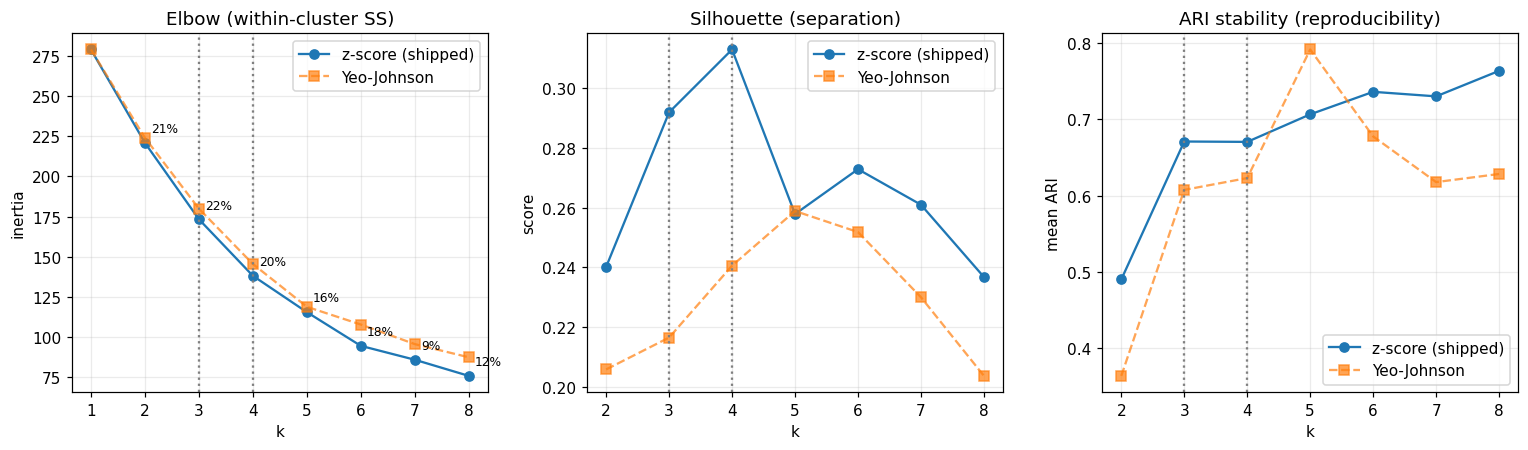

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
for a, (yz, yy, title, ylab) in zip(ax, [
        (inertia_z, inertia_y, 'Elbow (within-cluster SS)', 'inertia'),
        (sil_z,     sil_y,     'Silhouette (separation)',   'score'),
        (ari_z,     ari_y,     'ARI stability (reproducibility)', 'mean ARI')]):
    xs = ks if title.startswith('Elbow') else ks[1:]
    a.plot(xs, yz if title.startswith('Elbow') else yz[1:], 'o-', label='z-score (shipped)')
    a.plot(xs, yy if title.startswith('Elbow') else yy[1:], 's--', alpha=.7, label='Yeo-Johnson')
    a.axvline(3, color='gray', ls=':'); a.axvline(4, color='gray', ls=':')
    a.set_title(title); a.set_xlabel('k'); a.set_ylabel(ylab); a.legend()
for k, v, p in zip(ks, inertia_z, pct_drop):
    if not np.isnan(p):
        ax[0].annotate(f'{p:.0f}%', (k, v), textcoords='offset points', xytext=(4, 7), fontsize=8)
fig.tight_layout(); plt.show()

## 6. k = 3 vs k = 4 under k-means — what actually changes?

Fit both on the shipped (z-scored) features, align the k = 3 solution to the essay's A/B/C labels,
and cross-tabulate to see **which cluster splits** when a fourth is allowed.

In [11]:
df['k3'] = km_labels(Xz, 3)
df['k4'] = km_labels(Xz, 4)
amap = {n: df.loc[df['k3'] == n, 'cluster'].mode()[0] for n in sorted(df['k3'].unique())}
df['k3_lbl'] = df['k3'].map(amap)
print('k3 reproduction vs shipped CSV cluster labels:', f"{(df['k3_lbl'] == df['cluster']).mean():.0%}")
pd.crosstab(df['k3_lbl'], df['k4'], rownames=['k = 3 (A/B/C)'], colnames=['k = 4 cluster'])

k3 reproduction vs shipped CSV cluster labels: 90%


k = 4 cluster,0,1,2,3
k = 3 (A/B/C),,,,
A,0,0,0,6
B,4,0,0,0
C,0,18,3,0


In [12]:
for c in sorted(df['k4'].unique()):
    sub = df[df['k4'] == c]
    print(f"k4 cluster {c} (n={len(sub)}): {', '.join(sorted(sub['cdcr_code']))}")
print()
prof = df.groupby('k4')[FEATURES].mean().round(2)
prof.insert(0, 'n', df.groupby('k4').size())
prof.T

k4 cluster 0 (n=4): CAL, CEN, CHCF, ISP
k4 cluster 1 (n=18): ASP, CCWF, CIM, CIW, CMF, COR, CRC, FOL, KVSP, MCSP, NKSP, PVSP, SAC, SATF, SCC, SOL, VSP, WSP
k4 cluster 2 (n=3): CCI, HDSP, LAC
k4 cluster 3 (n=6): CMC, CTF, PBSP, RJD, SQ, SVSP



k4,0,1,2,3
n,4.00,18.00,3.00,6.00
year_opened,1998.00,1975.11,1980.67,1955.17
pct_hu_mechanical,1.00,0.13,0.04,0.12
pct_hu_evaporative,0.00,0.66,0.64,0.15
days_outdoor_above_78f_2025,177.25,156.17,126.67,33.50
days_indoor_above_78f_2025,45.00,121.44,81.00,52.00
uhi_normalized,0.09,0.35,0.01,0.06
elevation_m,25.00,122.56,1058.33,81.50
latitude,34.36,36.54,36.74,36.78
hotnights_pre_pct,6.29,7.02,10.04,3.28


**The k = 4 split is an elevation artifact.** The new cluster is the three
**high-elevation** prisons (CCI, HDSP, LAC; mean ≈ 1,000 m) carved out of the evaporative group —
and elevation is the single most-skewed feature (skew +2.7). So "k = 3 vs k = 4" and "fix the
elevation skew" are the *same* decision: a few extreme elevations manufacture a 4th cluster. This
is exactly the case for addressing skew/zeros and reconsidering the distance metric before k.

## 7. Preprocessing decision: address skew **and** zeros

Two changes, motivated above:

- **Skew** → Yeo-Johnson the continuous features (§4).
- **Zeros / composition** → the three cooling shares are a *composition*
  (`refrigeration + evaporative + ventilation ≈ 1`) and heavily zero-inflated. Representing them
  as one **categorical** variable — each facility's *dominant* cooling system — removes the
  zero-inflation and the redundancy, and matches how the essay actually talks about them.

In [13]:
cool_cols = ['pct_hu_mechanical', 'pct_hu_evaporative', 'pct_hu_air_handlers']
df['cooling_type'] = (df[cool_cols].idxmax(axis=1)
                      .str.replace('pct_hu_', '', regex=False))
print(df['cooling_type'].value_counts(), '\n')

# Numeric block (skewed continuous + counts + climate), Yeo-Johnson + standardized:
GOWER_NUM = ['year_opened', 'days_outdoor_above_78f_2025', 'days_indoor_above_78f_2025',
             'uhi_normalized', 'elevation_m', 'latitude', 'hotnights_pre_pct']
num_yj = PowerTransformer('yeo-johnson', standardize=True).fit_transform(df[GOWER_NUM])

# 'Improved' all-numeric matrix for a like-for-like k-means comparison: YJ numerics + one-hot cooling
cool_ohe = pd.get_dummies(df['cooling_type']).to_numpy(float)
X_improved = np.hstack([num_yj, StandardScaler().fit_transform(cool_ohe)])
print('X_improved shape:', X_improved.shape, '(7 YJ numeric + 3 one-hot cooling)')

cooling_type
evaporation      15
ventilation      11
refrigeration     5
Name: count, dtype: int64 



X_improved shape: (31, 10) (7 YJ numeric + 3 one-hot cooling)


## 8. Alternative: Gower distance + K-Medoids (PAM)

**Why consider it.** k-means *requires* Euclidean geometry, so every feature must be forced into
one continuous, comparably-scaled space — the source of the skew/zero problems above. **Gower
distance** instead computes a per-feature distance (range-normalized for numerics; 0/1 match for
categoricals) and averages them, so it takes the cooling **type** as a genuine category and never
needs the shares standardized. **K-Medoids / PAM** clusters from *any* distance matrix and uses
real facilities as centers, making it **robust to the elevation outliers** that drive the k-means
k = 4 split. Both are implemented below (n = 31, so cost is negligible) — no extra dependencies.

In [14]:
def gower_matrix(num_df, cat_df, num_w=None, cat_w=None):
    '''Gower dissimilarity in [0,1]: |dx|/range for numerics, 0/1 for categoricals, weighted mean.'''
    num = num_df.to_numpy(float); n = len(num_df)
    rng = num.max(0) - num.min(0); rng[rng == 0] = 1.0
    num_w = np.ones(num.shape[1]) if num_w is None else np.asarray(num_w, float)
    D = np.zeros((n, n)); W = 0.0
    for j in range(num.shape[1]):
        D += num_w[j] * np.abs(num[:, j][:, None] - num[:, j][None, :]) / rng[j]; W += num_w[j]
    cat = cat_df.to_numpy()
    cat_w = np.ones(cat.shape[1]) if cat_w is None else np.asarray(cat_w, float)
    for j in range(cat.shape[1]):
        D += cat_w[j] * (cat[:, j][:, None] != cat[:, j][None, :]).astype(float); W += cat_w[j]
    return D / W

def pam(D, k, max_iter=100):
    '''K-medoids (PAM build + swap) on a precomputed distance matrix. Deterministic.'''
    n = D.shape[0]
    medoids = [int(np.argmin(D.sum(1)))]
    while len(medoids) < k:
        cur = D[:, medoids].min(1); best, bc = None, np.inf
        for h in range(n):
            if h in medoids: continue
            c = np.minimum(cur, D[:, h]).sum()
            if c < bc: bc, best = c, h
        medoids.append(best)
    medoids = np.array(medoids)
    def cost_of(m):
        lab = np.argmin(D[:, m], 1); return lab, D[np.arange(n), m[lab]].sum()
    labels, cost = cost_of(medoids); improved = True; it = 0
    while improved and it < max_iter:
        improved = False; it += 1
        for mi in range(k):
            for h in range(n):
                if h in medoids: continue
                cand = medoids.copy(); cand[mi] = h
                lab, c = cost_of(cand)
                if c < cost - 1e-9:
                    medoids, labels, cost = cand, lab, c; improved = True
    return labels, medoids

# Build the Gower matrix: 7 YJ-numeric features (weight 1 each) + cooling_type (weight 1)
num_frame = pd.DataFrame(num_yj, columns=GOWER_NUM)
G = gower_matrix(num_frame, df[['cooling_type']])
print('Gower matrix:', G.shape, '| range [%.2f, %.2f]' % (G[np.triu_indices(31,1)].min(), G.max()))

Gower matrix: (31, 31) | range [0.03, 0.61]


In [15]:
# Scan k for all three pipelines: shipped k-means (z), improved k-means (YJ+cat), Gower+PAM
def pam_labels_sub(idx, k):        # for stability on the Gower matrix
    return pam(G[np.ix_(idx, idx)], k)[0]
def kmi_labels(idx, k):
    return km_labels(X_improved[idx], k)

kk = range(2, 7)
res = []
for k in kk:
    lz = km_labels(Xz, k)
    li = km_labels(X_improved, k)
    lg = pam(G, k)[0]
    res.append({
        'k': k,
        'sil_kmeans_z':   round(silhouette_score(Xz, lz), 3),
        'ARI_kmeans_z':   round(stability_ari(lambda i, k: km_labels(Xz[i], k), 31, k), 3),
        'sil_kmeans_yj':  round(silhouette_score(X_improved, li), 3),
        'ARI_kmeans_yj':  round(stability_ari(kmi_labels, 31, k), 3),
        'sil_gower_pam':  round(silhouette_score(G, lg, metric='precomputed'), 3),
        'ARI_gower_pam':  round(stability_ari(pam_labels_sub, 31, k), 3),
    })
scan_tbl = pd.DataFrame(res).set_index('k')
scan_tbl

,sil_kmeans_z,ARI_kmeans_z,sil_kmeans_yj,ARI_kmeans_yj,sil_gower_pam,ARI_gower_pam
k,,,,,,
2,0.240,0.490,0.218,0.637,0.271,0.572
3,0.292,0.671,0.276,0.851,0.249,0.553
4,0.313,0.670,0.268,0.703,0.327,0.701
5,0.258,0.706,0.272,0.673,0.280,0.785
6,0.273,0.736,0.221,0.692,0.283,0.758


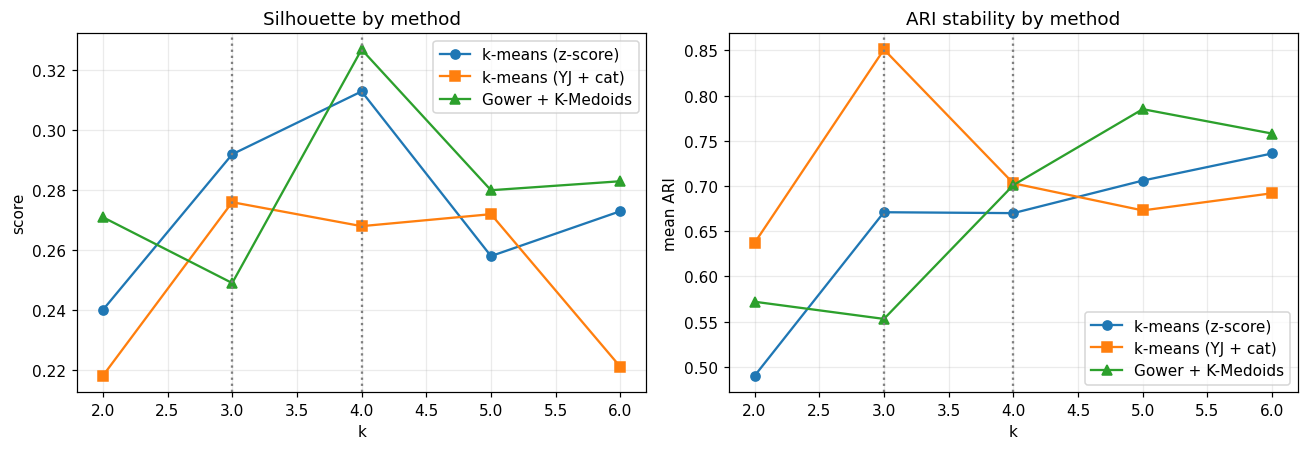

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(kk, scan_tbl['sil_kmeans_z'],  'o-', label='k-means (z-score)')
ax[0].plot(kk, scan_tbl['sil_kmeans_yj'], 's-', label='k-means (YJ + cat)')
ax[0].plot(kk, scan_tbl['sil_gower_pam'], '^-', label='Gower + K-Medoids')
ax[0].set_title('Silhouette by method'); ax[0].set_xlabel('k'); ax[0].set_ylabel('score'); ax[0].legend()
ax[1].plot(kk, scan_tbl['ARI_kmeans_z'],  'o-', label='k-means (z-score)')
ax[1].plot(kk, scan_tbl['ARI_kmeans_yj'], 's-', label='k-means (YJ + cat)')
ax[1].plot(kk, scan_tbl['ARI_gower_pam'], '^-', label='Gower + K-Medoids')
ax[1].set_title('ARI stability by method'); ax[1].set_xlabel('k'); ax[1].set_ylabel('mean ARI'); ax[1].legend()
for a in ax:
    a.axvline(3, color='gray', ls=':'); a.axvline(4, color='gray', ls=':')
fig.tight_layout(); plt.show()

**Gower + K-Medoids memberships**, and how much they agree with the shipped k-means (ARI):

In [17]:
for k in (3, 4):
    lg = pam(G, k)[0]
    print(f'--- Gower+PAM, k={k} ---')
    for c in sorted(set(lg)):
        codes = df.loc[lg == c, 'cdcr_code']
        print(f'  cluster {c} (n={len(codes)}): {", ".join(sorted(codes))}')
    print(f'  ARI vs shipped k-means(z) k={k}: {adjusted_rand_score(km_labels(Xz, k), lg):.3f}\n')

--- Gower+PAM, k=3 ---
  cluster 0 (n=18): ASP, CAL, CCWF, CEN, CHCF, COR, FOL, HDSP, ISP, KVSP, LAC, MCSP, NKSP, PVSP, SAC, SATF, VSP, WSP
  cluster 1 (n=7): CCI, CMC, CTF, PBSP, RJD, SQ, SVSP
  cluster 2 (n=6): CIM, CIW, CMF, CRC, SCC, SOL
  ARI vs shipped k-means(z) k=3: 0.285

--- Gower+PAM, k=4 ---
  cluster 0 (n=14): ASP, CCWF, COR, FOL, HDSP, KVSP, LAC, MCSP, NKSP, PVSP, SAC, SATF, VSP, WSP
  cluster 1 (n=7): CCI, CMC, CTF, PBSP, RJD, SQ, SVSP
  cluster 2 (n=6): CIM, CIW, CMF, CRC, SCC, SOL
  cluster 3 (n=4): CAL, CEN, CHCF, ISP
  ARI vs shipped k-means(z) k=4: 0.502



## 9. Adopting the improved preprocessing — what it changes

Apply the two fixes as the *actual* pipeline: Yeo-Johnson numerics + categorical dominant cooling
+ the SATF data fix, k-means at k = 3. The result is internally very stable (resample ARI ≈ 0.85),
**but it is a different partition** from the shipped A/B/C labels — only ~74% overlap
(ARI ≈ 0.33), with 8 facilities moving. The movers are defensible (e.g. **FOL** and **SVSP** are
evaporative-cooled and warm, so they leave the "cool climate" cluster for the evaporative one) —
but this means adopting the fix **re-tells the cluster story**, it is not a cosmetic change.

In [18]:
dfi = df.copy()
dfi.loc[dfi.cdcr_code == 'SATF', 'pct_hu_evaporative'] = \
    dfi.loc[dfi.cdcr_code == 'SATF', 'pct_hu_evaporative'].clip(upper=1.0)

num_yj2 = PowerTransformer('yeo-johnson', standardize=True).fit_transform(dfi[GOWER_NUM])
ohe2    = pd.get_dummies(dfi['cooling_type']).to_numpy(float)
X_imp   = np.hstack([num_yj2, StandardScaler().fit_transform(ohe2)])

dfi['imp'] = KMeans(3, random_state=RANDOM_STATE, n_init=50).fit_predict(X_imp)
amap = {n: dfi.loc[dfi['imp'] == n, 'cluster'].mode()[0] for n in sorted(dfi['imp'].unique())}
dfi['imp_lbl'] = dfi['imp'].map(amap)
print('improved-k3 vs shipped A/B/C: '
      f"{(dfi.imp_lbl == dfi.cluster).mean():.0%} overlap, ARI={adjusted_rand_score(dfi.cluster, dfi.imp_lbl):.3f}")
movers = (dfi[dfi.imp_lbl != dfi.cluster]
          [['cdcr_code', 'cluster', 'imp_lbl', 'cooling_type',
            'elevation_m', 'days_outdoor_above_78f_2025', 'days_indoor_above_78f_2025']]
          .rename(columns={'cluster': 'shipped', 'imp_lbl': 'improved'}))
movers

improved-k3 vs shipped A/B/C: 74% overlap, ARI=0.327


,cdcr_code,shipped,improved,cooling_type,elevation_m,days_outdoor_above_78f_2025,days_indoor_above_78f_2025
5,FOL,A,C,evaporation,83.0,144,158
6,SOL,C,A,ventilation,42.0,146,159
7,SCC,C,A,ventilation,329.0,148,154
8,CIM,B,A,ventilation,189.0,162,161
10,CRC,C,A,ventilation,199.0,155,149
12,CMF,C,B,refrigeration,43.0,146,135
23,KVSP,C,A,ventilation,77.0,162,66
28,SVSP,A,C,evaporation,88.0,31,1


Cluster profiles under the improved pipeline (means) — the new A/B/C:

In [19]:
prof_i = dfi.groupby('imp_lbl')[FEATURES].mean().round(2)
prof_i.insert(0, 'n', dfi.groupby('imp_lbl').size())
prof_i.T

imp_lbl,A,B,C
n,11.00,5.00,15.00
year_opened,1958.73,1989.40,1981.60
pct_hu_mechanical,0.13,0.91,0.08
pct_hu_evaporative,0.03,0.09,0.93
days_outdoor_above_78f_2025,93.91,171.00,147.53
days_indoor_above_78f_2025,101.36,63.00,99.40
uhi_normalized,0.24,0.18,0.23
elevation_m,220.82,28.60,226.53
latitude,36.29,35.16,36.74
hotnights_pre_pct,5.31,6.33,7.42


## 10. What "up-weighting cooling" means (Gower)

Gower distance is a **weighted average of per-feature distances**:

$$D_{ij} = \frac{\sum_f w_f\, d_f(i,j)}{\sum_f w_f}$$

In §8 every feature had weight 1, so with 7 numeric features + 1 cooling category, **cooling is
1/8 ≈ 12% of the distance**. But several of the seven numerics (outdoor days, hot nights, latitude,
UHI, elevation) are partly *proxies for the same climate/geography dimension*, so "climate"
collectively owns ~88% of the distance and the **cooling-type** distinction — the essay's core
variable — washes out. Two prisons in the same hot valley become neighbors whether one runs
refrigerated AC and the other a swamp cooler.

**Up-weighting** simply raises `w_cooling`. Setting it to `w` makes cooling count like `w` numeric
features; `w ≈ 7` gives cooling and climate roughly equal say. The `gower_matrix` helper already
takes `cat_w`, so it is a one-argument change. The sweep shows the clustering realigning toward the
cooling-driven structure (higher ARI vs the shipped A/B/C) as cooling's share of the distance rises:

In [20]:
sweep = []
for w in [1, 2, 3, 5, 7]:
    Gw = gower_matrix(num_frame, df[['cooling_type']], cat_w=[w])
    lg = pam(Gw, 3)[0]
    sweep.append({'cooling_weight': w,
                  'cooling_%_of_distance': round(w / (len(GOWER_NUM) + w) * 100),
                  'silhouette': round(silhouette_score(Gw, lg, metric='precomputed'), 3),
                  'ARI_stability': round(stability_ari(lambda i, k: pam(gower_matrix(num_frame.iloc[i], df[['cooling_type']].iloc[i], cat_w=[w]), k)[0], 31, 3), 3),
                  'ARI_vs_shipped_ABC': round(adjusted_rand_score(df['cluster'], lg), 3),
                  'sizes': tuple(pd.Series(lg).value_counts().sort_index().tolist())})
pd.DataFrame(sweep)

,cooling_weight,cooling_%_of_distance,silhouette,ARI_stability,ARI_vs_shipped_ABC,sizes
0,1,12,0.249,0.532,0.333,"(18, 7, 6)"
1,2,22,0.517,0.865,0.327,"(15, 11, 5)"
2,3,30,0.614,0.972,0.327,"(15, 11, 5)"
3,5,42,0.725,0.993,0.327,"(15, 11, 5)"
4,7,50,0.786,0.997,0.327,"(15, 11, 5)"


## 11. Clustering as description only — construct-balanced, nothing privileged

Per the review, clustering cannot identify *determinants*, and any partition mostly reflects how the
inputs are weighted. So here clustering is treated as **description only**, with the privileging
removed:

- **skew** handled (Yeo-Johnson);
- **cooling** enters as one *category*, not three one-hot columns, so it can't dominate by column count;
- **redundancy** handled by weighting *constructs* equally — the six correlated climate/geography
  proxies share weight 1 between them, cooling = 1, building age = 1;
- the **outcome** (indoor days) is *excluded* — facilities are described by characteristics only.

If the three-group structure only appeared when we over-weighted cooling, it would be an artifact.
It isn't:

In [21]:
CLIM = ['days_outdoor_above_78f_2025', 'hotnights_pre_pct', 'avg_tmin_f_2025',
        'latitude', 'elevation_m', 'uhi_normalized']
num_feats_n = CLIM + ['year_opened']
num_w_n = [1/len(CLIM)] * len(CLIM) + [1.0]          # climate block = 1, age = 1, (cooling = 1 below)
nfr = pd.DataFrame(PowerTransformer('yeo-johnson', standardize=True).fit_transform(df[num_feats_n]),
                   columns=num_feats_n)
Gn = gower_matrix(nfr, df[['cooling_type']], num_w=num_w_n, cat_w=[1.0])

for k in range(2, 7):
    l = pam(Gn, k)[0]
    print(f'k={k}: silhouette = {silhouette_score(Gn, l, metric="precomputed"):.3f}')

k=2: silhouette = 0.525
k=3: silhouette = 0.683
k=4: silhouette = 0.539
k=5: silhouette = 0.501
k=6: silhouette = 0.417


In [22]:
ln = pam(Gn, 3)[0]
print('neutral k=3 == the three cooling regimes?  ARI vs cooling_type =',
      round(adjusted_rand_score(df['cooling_type'], ln), 3))
pd.crosstab(pd.Series(ln, name='neutral_cluster'), df['cooling_type'])

neutral k=3 == the three cooling regimes?  ARI vs cooling_type = 1.0


cooling_type,evaporation,refrigeration,ventilation
neutral_cluster,,,
0,15,0,0
1,0,0,11
2,0,5,0


**The three-group structure is robust, not imposed.** Even with cooling given only equal footing
(one of three constructs), skew corrected, and the outcome excluded, k = 3 is the best-separated
solution (silhouette ≈ 0.68) and the clusters are *still* exactly the three cooling regimes
(ARI = 1.0). Cooling type, building age, and climate co-vary — refrigerated = newer desert,
ventilation = older, evaporative = valley — so every construct points to the same split. That makes
the cooling-regime grouping a **defensible description**. It still does not say which variable
*determines* indoor heat; for that, model the outcome directly (next).

## 12. Which variables *determine* exposure — a direct model

Clustering groups similar facilities; it can't say which variable drives indoor heat. To answer that,
model the **exposure outcome** on the candidates competing on equal footing (standardized). n = 31 is
small, so lead with univariate screening, keep multivariable models tiny, and report **leave-one-out
CV R²** — in-sample R² flatters with few points, and a negative LOO R² means the model predicts worse
than the mean (overfit, not informative).

Two outcomes:
- **indoor days > 78°F** — absolute exposure (climate + building);
- **indoor / outdoor ratio** — how much the building *amplifies* outdoor heat (climate divided out;
  the cleanest "what is the building doing" outcome). PBSP (ratio 15.8) excluded as an outlier.

In [23]:
from scipy.stats import pearsonr, t as tdist
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict

dd = df.copy()
dd['envelope_recent'] = dd['envelope_work'].astype(str).str.contains(r'(?:19|20)\d\d', regex=True).astype(int)
PRED = ['pct_hu_mechanical', 'pct_hu_evaporative', 'year_opened', 'elevation_m',
        'uhi_normalized', 'latitude', 'hotnights_pre_pct', 'avg_tmin_f_2025', 'envelope_recent']

def univariate(data, y, preds):
    rows = []
    for p in preds:
        s = data[[p, y]].dropna(); r, pv = pearsonr(s[p], s[y])
        rows.append({'predictor': p, 'r': round(r, 3), 'R2': round(r**2, 3), 'p': round(pv, 3)})
    return pd.DataFrame(rows).sort_values('R2', ascending=False).reset_index(drop=True)

def ols_stats(X, y):
    Xc = np.column_stack([np.ones(len(X)), X]); beta, *_ = np.linalg.lstsq(Xc, y, rcond=None)
    resid = y - Xc @ beta; n, p = Xc.shape
    r2 = 1 - (resid @ resid) / ((y - y.mean()) @ (y - y.mean())); adj = 1 - (1 - r2) * (n - 1) / (n - p)
    se = np.sqrt(np.diag((resid @ resid) / (n - p) * np.linalg.inv(Xc.T @ Xc)))
    return beta, 2 * (1 - tdist.cdf(np.abs(beta / se), n - p)), r2, adj

def model(data, y, preds):
    s = data[preds + [y]].dropna(); X = StandardScaler().fit_transform(s[preds]); yy = s[y].values
    beta, pv, r2, adj = ols_stats(X, yy)
    cvp = cross_val_predict(LinearRegression(), X, yy, cv=LeaveOneOut())
    cv = 1 - ((yy - cvp) ** 2).sum() / ((yy - yy.mean()) ** 2).sum()
    return {'adj': adj, 'cv': cv, 'beta': beta[1:], 'pv': pv[1:], 'preds': preds}

d_ratio = dd[dd.ratio_indoor_to_outdoor < 10]        # drop PBSP outlier
uni_ratio  = univariate(d_ratio, 'ratio_indoor_to_outdoor', PRED)
uni_indoor = univariate(dd, 'days_indoor_above_78f_2025', PRED + ['days_outdoor_above_78f_2025'])
print('Univariate importance vs indoor/outdoor RATIO (building amplification):')
uni_ratio

Univariate importance vs indoor/outdoor RATIO (building amplification):


,predictor,r,R2,p
0,year_opened,-0.530,0.281,0.003
1,pct_hu_mechanical,-0.328,0.108,0.077
2,pct_hu_evaporative,-0.264,0.070,0.158
3,avg_tmin_f_2025,-0.262,0.069,0.161
4,hotnights_pre_pct,-0.169,0.028,0.373
5,envelope_recent,0.155,0.024,0.415
6,uhi_normalized,0.074,0.005,0.699
7,elevation_m,0.063,0.004,0.739
8,latitude,-0.033,0.001,0.863


In [24]:
print('Univariate importance vs INDOOR days > 78F (absolute exposure):')
uni_indoor

Univariate importance vs INDOOR days > 78F (absolute exposure):


,predictor,r,R2,p
0,uhi_normalized,0.476,0.227,0.007
1,days_outdoor_above_78f_2025,0.321,0.103,0.078
2,pct_hu_mechanical,-0.227,0.052,0.219
3,year_opened,-0.199,0.040,0.284
4,hotnights_pre_pct,0.195,0.038,0.293
5,pct_hu_evaporative,0.136,0.019,0.464
6,avg_tmin_f_2025,0.074,0.005,0.694
7,latitude,-0.065,0.004,0.729
8,envelope_recent,0.045,0.002,0.810
9,elevation_m,0.034,0.001,0.857


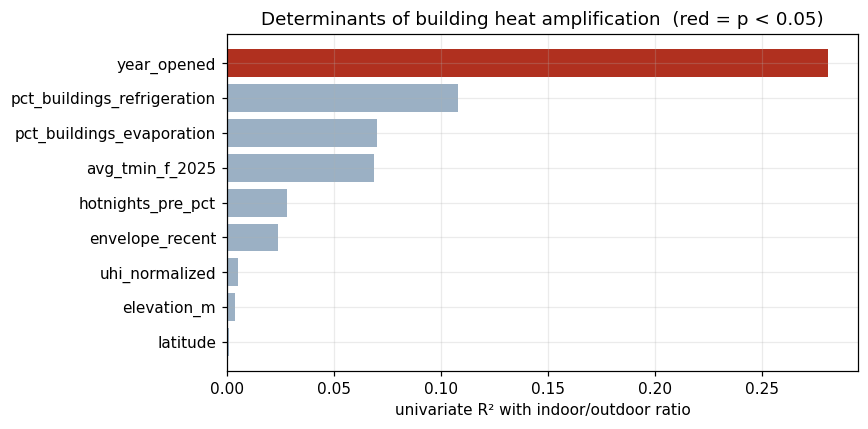

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))
u = uni_ratio.sort_values('R2')
ax.barh(u['predictor'], u['R2'], color=['#b0301f' if p < 0.05 else '#9bb0c4' for p in u['p']])
ax.set_xlabel('univariate R² with indoor/outdoor ratio')
ax.set_title('Determinants of building heat amplification  (red = p < 0.05)')
fig.tight_layout(); plt.show()

In [26]:
rows = []
for nm, preds in [('ratio ~ refrigeration',          ['pct_hu_mechanical']),
                  ('ratio ~ building age',           ['year_opened']),
                  ('ratio ~ age + refrig + overnight',['year_opened', 'pct_hu_mechanical', 'avg_tmin_f_2025']),
                  ('ratio ~ all 9 predictors',       PRED)]:
    m = model(d_ratio, 'ratio_indoor_to_outdoor', preds)
    rows.append({'model': nm, 'n_pred': len(preds), 'adj_R2': round(m['adj'], 2), 'LOO_R2': round(m['cv'], 2)})
for nm, preds in [('indoor ~ outdoor (climate only)', ['days_outdoor_above_78f_2025']),
                  ('indoor ~ outdoor + refrigeration',['days_outdoor_above_78f_2025', 'pct_hu_mechanical']),
                  ('indoor ~ outdoor + all building', ['days_outdoor_above_78f_2025'] + PRED)]:
    m = model(dd, 'days_indoor_above_78f_2025', preds)
    rows.append({'model': nm, 'n_pred': len(preds), 'adj_R2': round(m['adj'], 2), 'LOO_R2': round(m['cv'], 2)})
pd.DataFrame(rows)

,model,n_pred,adj_R2,LOO_R2
0,ratio ~ refrigeration,1,0.08,-0.01
1,ratio ~ building age,1,0.26,0.17
2,ratio ~ age + refrig + overnight,3,0.27,0.17
3,ratio ~ all 9 predictors,9,0.26,-0.38
4,indoor ~ outdoor (climate only),1,0.07,-0.00
5,indoor ~ outdoor + refrigeration,2,0.17,0.04
6,indoor ~ outdoor + all building,10,0.30,-0.22


**What the model says.**

- The strongest *measured* determinant of how much a building amplifies outdoor heat is **building
  age** (r = −0.53, R² = 0.28, p = 0.003): older buildings run hotter inside per degree outside —
  consistent with uninsulated concrete, thermal mass, and degraded systems.
- **Refrigeration** is a weak second (R² = 0.11, p = 0.08). Everything the earlier analysis leaned on
  — UHI, elevation, latitude, overnight temperature, envelope work — explains essentially nothing on
  its own.
- Even the best small model (age + refrigeration + overnight) reaches only adj R² ≈ 0.27 and
  **leave-one-out R² ≈ 0.17** — roughly **80% of the variation in what buildings do to heat is
  unexplained by any measured variable**. Adding all nine predictors *lowers* out-of-sample R² (LOO
  goes negative): more variables, less understanding, at n = 31.

So the determinants question resolves to **building age (clear) > cooling (weak) ≫ site/climate
proxies (null), with most of the signal missing** — the quantitative case for publishing continuous
indoor temperatures, made without leaning on the clustering.

## 13. Decision digest

In [27]:
skewed   = [f for f in FEATURES if abs(skew(df[f])) > 1]
zeroinfl = cont.loc[cont.pct_zero > 25, 'feature'].tolist()
best = lambda s: int(scan_tbl.index[np.argmax(scan_tbl[s])])

print('DECISION DIGEST\n' + '-' * 64)
print('Continuity / scaling')
print(f'  skewed (|skew|>1)         : {skewed}')
print(f'  zero-inflated (>25% zeros): {zeroinfl}')
print('  -> StandardScaler leaves skew unchanged; Yeo-Johnson fixes the continuous ones;')
print('     the cooling shares are compositional -> better as one categorical (dominant type).')
print('  -> data fix: pct_hu_evaporative = 1.03 at SATF (should be <=1).')
print('\nHow many clusters (elbow is smooth; trust silhouette + ARI stability)')
print(f'  shipped k-means (z) : silhouette best k={best("sil_kmeans_z")}, ARI-stable best k={best("ARI_kmeans_z")}')
print(f'  improved k-means(YJ): silhouette best k={best("sil_kmeans_yj")}, ARI-stable best k={best("ARI_kmeans_yj")}')
print(f'  Gower + K-Medoids   : silhouette best k={best("sil_gower_pam")}, ARI-stable best k={best("ARI_gower_pam")}')
print('\nk=3 vs k=4: the raw k-means k=4 cluster is just the 3 high-elevation prisons (CCI/HDSP/LAC),')
print('an artifact of the elevation skew. After the fix, k=3 is the most stable choice.')
print('\nAdopted pipeline (YJ + categorical cooling + SATF fix), k=3:')
print(f'  vs shipped A/B/C: {(dfi.imp_lbl==dfi.cluster).mean():.0%} overlap ({(dfi.imp_lbl!=dfi.cluster).sum()} movers) -> the cluster story changes.')
print('  Gower+PAM cooling weight is the lever: w=1 -> climate-driven; w~7 -> cooling-driven (see sweep).')
print('\nClustering is DESCRIPTION only: the 3 cooling regimes are the robust k=3 grouping even under')
print('neutral construct-balanced weighting (ARI 1.0), but a grouping is not a determinant.')
print('\nDeterminants (direct model of the exposure outcome, variables on equal footing):')
print(f'  strongest measured driver of building heat-amplification: {uni_ratio.iloc[0].predictor} '
      f'(R2={uni_ratio.iloc[0].R2}, p={uni_ratio.iloc[0].p})')
print('  order: building AGE (clear) > refrigeration (weak) >> UHI / elevation / latitude (null).')
print('  best small model: adj R2 ~0.27, leave-one-out R2 ~0.17  -> ~80% unexplained by measured vars')
print('  -> the quantitative case for publishing continuous indoor temperatures.')

DECISION DIGEST
----------------------------------------------------------------
Continuity / scaling
  skewed (|skew|>1)         : ['year_opened', 'pct_hu_mechanical', 'days_outdoor_above_78f_2025', 'elevation_m']
  zero-inflated (>25% zeros): ['pct_hu_mechanical', 'pct_hu_evaporative', 'uhi_normalized']
  -> StandardScaler leaves skew unchanged; Yeo-Johnson fixes the continuous ones;
     the cooling shares are compositional -> better as one categorical (dominant type).
  -> data fix: pct_hu_evaporative = 1.03 at SATF (should be <=1).

How many clusters (elbow is smooth; trust silhouette + ARI stability)
  shipped k-means (z) : silhouette best k=4, ARI-stable best k=6
  improved k-means(YJ): silhouette best k=3, ARI-stable best k=3
  Gower + K-Medoids   : silhouette best k=4, ARI-stable best k=5

k=3 vs k=4: the raw k-means k=4 cluster is just the 3 high-elevation prisons (CCI/HDSP/LAC),
an artifact of the elevation skew. After the fix, k=3 is the most stable choice.

Adopted pipelin